---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Topic**: You Can Just Build Things

🚫 **Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

## Welcome!

In our firstfour lectures, we've covered how
1. We can call LLMs via APIs and get structured responses
2. We can build lexical search with BM25
3. We can build semantic search with embeddings
4. We can combine lexical and semantic search into hybrid search

Today you will put it all together by building a Retrieval Augmented Generation (RAG) system.
- This is a question-answering bot that can answer questions about Fordham University
- You will use real data scraped from the Fordham website.


Your RAG pipeline will look like this:

```
User Question
     ↓
1. RETRIEVE: Find relevant documents (search!)
     ↓
2. AUGMENT: Stuff those documents into a prompt
     ↓
3. GENERATE: Ask an LLM to answer using the context
     ↓
Answer
```


---

# 1. Look at your data

In `data/fordham-website.zip` you'll find **~9,500 Markdown files** scraped from Fordham's website. Each file is one page — admissions info, program descriptions, faculty pages, financial aid, campus life, and more.

Your task: **look at the data**
- The first step in any AI engineering or data science project should always be to familiarize yourself with the data.
- I cannot stress this enough.. without this step, it's hard to build anything useful.

Tips:
- Unzip the archive and look at some of the files. 
- Open a few in a text editor. 
- Get a feel for what you're working with.
- The first line of every file is always the **URL** of the page it was scraped from. The rest is the page content converted to Markdown. Here's an example — `gabelli-school-of-business_veterans.md`:

```markdown
https://www.fordham.edu/gabelli-school-of-business/veterans

# Military Veterans & Active Duty Members of the Military

## Transform Your Knowledge & Skills Into a Business Career for the Future

As a veteran or an active duty member of the United States Armed Services,
you have gained or are currently acquiring the invaluable organizational,
leadership, analytics, and technical knowledge and skills that hiring
managers seek. These transferrable skills provide a major advantage in
emerging, business-related industries where innovation, a global mind-set,
and the ability to lead individuals and teams in the continuously evolving
work environment, are critical for success.

By completing a graduate or undergraduate business degree at the Gabelli
School of Business, you can prepare for a lifelong career in some of
today's fastest-growing fields. ...

### Study at a Top-Ranked, Military-Friendly University

The Gabelli School of Business is part of Fordham University, the only
New York City university to be among those ranked "Best for Vets" by
Military Times. ...

### Learn How the Yellow Ribbon Program Works

The Yellow Ribbon GI Education Enhancement Program, or the Yellow Ribbon
Program, is a part of the Post-9/11 Veterans Educational Assistance Act
of 2008. ...
```

The filenames mirror the URL structure — underscores replace path separators (e.g. `gabelli-school-of-business_veterans.md` came from `/gabelli-school-of-business/veterans`). Some files are short (a few lines), others are quite long.

- Once you've looked around, load the files into Python. Python's built-in `zipfile` module can read zip archives without extracting to disk. Load them into a list of dictionaries or a DataFrame with at least two fields: the filename (or a clean page name) and the content

In [1]:
import zipfile
import pandas as pd
import os

# Path to the zip file — resolve relative to notebook location to avoid fragile paths
NOTEBOOK_DIR = os.path.abspath("")
zip_path = os.path.join(NOTEBOOK_DIR, "data", "fordham-website.zip")

documents = []

with zipfile.ZipFile(zip_path, "r") as zf:
    for name in zf.namelist():
        if name.endswith(".md"):
            content = zf.read(name).decode("utf-8")
            lines = content.split("\n", 1)
            url = lines[0].strip()
            body = lines[1].strip() if len(lines) > 1 else ""
            filename = os.path.basename(name)
            documents.append({"filename": filename, "url": url, "content": body})

df = pd.DataFrame(documents)
df["content_length"] = df["content"].str.len()

print(f"Loaded {len(df)} documents")
print(f"\nColumns: {list(df.columns)}")
print(f"\n--- Content length stats (characters) ---")
print(df["content_length"].describe())

for i in range(3):
    doc = df.iloc[i]
    print()
    print("=" * 80)
    print("FILE:", doc["filename"])
    print("URL: ", doc["url"])
    print("LENGTH:", doc["content_length"], "characters")
    print("-" * 80)
    preview = doc["content"][:500]
    print(preview)
    if len(doc["content"]) > 500:
        print("...")

df.head()


Loaded 9551 documents

Columns: ['filename', 'url', 'content', 'content_length']

--- Content length stats (characters) ---
count      9551.000000
mean       4180.511255
std        9014.640900
min         103.000000
25%        1268.000000
50%        2269.000000
75%        4365.500000
max      431113.000000
Name: content_length, dtype: float64

FILE: index.md
URL:  https://www.fordham.edu/
LENGTH: 1802 characters
--------------------------------------------------------------------------------
## Doing Good That Becomes Greater As The Jesuit University of New York

We’re located in New York City—driven by our Jesuit values and tackling today’s most pressing issues at the center of the world stage.

## We Are Leaders, Dreamers, Achievers, And Doers

With sound hearts, strong minds, and the wisdom to take charge, generations of Rams have found what they have needed to grow—the opportunities, connections, and support of this community.

## From Winding Elms to Bustling City Blocks

With 
..

,filename,url,content,content_length
0,index.md,https://www.fordham.edu/,## Doing Good That Becomes Greater As The Jesu...,1802
1,research.md,https://www.fordham.edu/research,Uncovering the Limitless Possibilities of Scie...,2805
2,ccel.md,https://www.fordham.edu/ccel,# Center for Community Engaged Learning\n\n###...,967
3,fordham-college-at-lincoln-center.md,https://www.fordham.edu/fordham-college-at-lin...,# Fordham College at Lincoln Center\n\n## Why ...,2056
4,academics.md,https://www.fordham.edu/academics,# Academics\n\n## 8 schools. 3 campuses.\n\n![...,1074


---

# 2. Chunk the Documents

Some of the pages could be too long to embed as a single unit. Down the line, the pages may be too long to stuff into the LLM's prompt during the generation step. As such, most of the RAG systems will break down big documents into into smaller **chunks**.

> 📚 **TERM: Chunking**  
> Splitting documents into smaller, self-contained pieces for embedding and retrieval. The goal is chunks that are small enough to be specific, but large enough to be meaningful.

Your task: **write a function that splits each document into chunks.**

Things to think about:
- What's a reasonable chunk size? (Think about what fits in a prompt vs. what's too vague)
- Should you split on sentences? Paragraphs? A fixed character/word count?
- Should chunks overlap? What happens if an answer spans two chunks?
- How do you keep track of which document each chunk came from? You may need that information down the line.

In [2]:
# ==========================================
# 2. CHUNK THE DOCUMENTS
# Improvements:
#   - Parallel processing with multiprocessing.Pool (uses all CPU cores)
#   - Disk caching: only chunks once, then loads from cache on every subsequent run
#   - chunk_overlap is now actually applied via sliding window on overflow paragraphs
# ==========================================
import re
import os
import pickle
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

CHUNKS_FILE = os.path.join(NOTEBOOK_DIR, "data", "chunks.pkl")

def chunk_document(text, chunk_size=800, chunk_overlap=200):
    """
    Smart Markdown Chunker. Respects headers and preserves context.
    Splits on H1-H3 headers first; falls back to paragraph splitting
    with the section header prepended to maintain context.
    chunk_overlap is applied when a section overflows into multiple chunks.
    """
    sections = re.split(r"(^#{1,3} .*$)", text, flags=re.MULTILINE)

    chunks = []
    current_chunk = ""
    current_header = ""

    for part in sections:
        part = part.strip()
        if not part:
            continue

        if re.match(r"^#{1,3} ", part):
            current_header = part
            if current_chunk:
                chunks.append(current_chunk.strip())
            current_chunk = current_header + "\n"
            continue

        if len(current_chunk) + len(part) < chunk_size:
            current_chunk += part + "\n\n"
        else:
            paras = part.split("\n\n")
            overlap_buffer = []
            for para in paras:
                if len(current_chunk) + len(para) > chunk_size:
                    chunks.append(current_chunk.strip())
                    # Apply overlap: carry the last N chars of previous chunk
                    overlap_text = "\n".join(overlap_buffer[-2:])  # last 2 paras as overlap
                    current_chunk = current_header + "\n" + overlap_text + "\n" + para + "\n"
                    overlap_buffer = [para]
                else:
                    current_chunk += para + "\n"
                    overlap_buffer.append(para)

    if current_chunk.strip():
        chunks.append(current_chunk.strip())

    return chunks


def process_row(row_dict):
    """Process a single document — must be top-level function for multiprocessing."""
    content = str(row_dict["content"]) if row_dict["content"] else ""
    if not content:
        return []
    return [
        {"text": chunk, "filename": row_dict["filename"], "url": row_dict["url"]}
        for chunk in chunk_document(content)
        if chunk.strip()
    ]


# --- CACHING: Skip chunking if already done ---
if os.path.exists(CHUNKS_FILE):
    with open(CHUNKS_FILE, "rb") as f:
        all_chunks = pickle.load(f)
    print(f"✅ Loaded {len(all_chunks)} cached chunks from disk (chunking skipped)")
else:
    cores = cpu_count()
    print(f"⚙️  Chunking {len(df)} documents using {cores} CPU cores...")
    rows = df.to_dict("records")

    with Pool(cores) as pool:
        results = list(tqdm(pool.imap(process_row, rows), total=len(rows)))

    all_chunks = [chunk for doc_chunks in results for chunk in doc_chunks]

    with open(CHUNKS_FILE, "wb") as f:
        pickle.dump(all_chunks, f)

    print(f"✅ {len(all_chunks)} chunks saved to cache at {CHUNKS_FILE}")

print(f"\nActive Strategy: Smart Context-Aware Chunking")
print(f"Total Chunks: {len(all_chunks)}")


⚙️  Chunking 9551 documents using 16 CPU cores...


100%|██████████| 9551/9551 [00:02<00:00, 4740.06it/s]


✅ 83230 chunks saved to cache at /home/joelebukatobi/projects/ai-engineering-fordham/data/chunks.pkl

Active Strategy: Smart Context-Aware Chunking
Total Chunks: 83230


---

# 3. Embed the Chunks

Now we need to turn each chunk into a vector so we can search over them. You've done this before in Lecture 4.

Your task: **embed all chunks using an embedding model.**

Tips:
- You could use a local model, or API model. What are the tradeoffs?
- This will take a while if you do it serially. You might want to use async/batch.
- Once you've created your embeddings, you may want to save them to disk so you don't have to redo this step every time
- You'll need to embed queries with the **same model** at search time

In [3]:
# ==========================================
# 3. EMBED THE CHUNKS (Local Model — No API costs, no rate limits)
# Improvements:
#   - Uses sentence-transformers (already installed) instead of OpenAI API
#   - Batch size 256 — uses all available CPU/GPU automatically
#   - Disk caching: only embeds once, then loads from cache
# ==========================================
import os
import pickle
import numpy as np
from sentence_transformers import SentenceTransformer

if "all_chunks" not in dir() or len(all_chunks) == 0:
    raise RuntimeError("⚠️ ERROR: 'all_chunks' not defined. Run the chunking cell first!")

EMBEDDING_FILE = os.path.join(NOTEBOOK_DIR, "data", "embeddings_local.pkl")
MODEL_NAME = "all-MiniLM-L6-v2"  # Fast, good quality, 384-dim vectors

# --- CACHING: Skip embedding if already done ---
if os.path.exists(EMBEDDING_FILE):
    print(f"✅ Loading cached embeddings from {EMBEDDING_FILE}...")
    with open(EMBEDDING_FILE, "rb") as f:
        data = pickle.load(f)
    vectors = data["vectors"]
    print(f"   Loaded {len(vectors)} vectors (dim={len(vectors[0])})")
else:
    print(f"🚀 Generating embeddings with local model: {MODEL_NAME}")
    print(f"   {len(all_chunks)} chunks to embed — no API costs, no rate limits!")

    embed_model = SentenceTransformer(MODEL_NAME)
    texts = [c["text"] for c in all_chunks]

    # Encodes all chunks with large batch — much faster than per-item loop
    embeddings = embed_model.encode(
        texts,
        batch_size=256,
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    vectors = embeddings.tolist()

    with open(EMBEDDING_FILE, "wb") as f:
        pickle.dump({"chunks": all_chunks, "vectors": vectors}, f)

    print(f"✅ Saved {len(vectors)} embeddings to {EMBEDDING_FILE}")


/home/joelebukatobi/projects/ai-engineering-fordham/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Generating embeddings with local model: all-MiniLM-L6-v2
   83230 chunks to embed — no API costs, no rate limits!


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 469.49it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 326/326 [39:48<00:00,  7.33s/it]


✅ Saved 83230 embeddings to /home/joelebukatobi/projects/ai-engineering-fordham/data/embeddings_local.pkl


---

# 4. Retrieve

Now build the **R** in RAG. Given a user's question, find the most relevant chunks.

Your task: **write a retrieval function that takes a question and returns the most relevant chunks.**

Tips:
- You can use lexical or semantic search or both!
- How many chunks should you retrieve? Too few and you might miss the answer; too many and you'll overwhelm the LLM (and pay more tokens)
- Try a few test questions and eyeball whether the retrieved chunks are relevant
- Try a few questions and see what comes back. For example:
  - "What programs does the Gabelli School of Business offer?"
  - "How do I apply for financial aid?"
  - "Where is Fordham's campus?"

In [4]:
# ==========================================
# 4. RETRIEVE — FAISS Index (fast approximate nearest neighbor)
# Improvements:
#   - FAISS replaces sklearn cosine_similarity
#   - Query time: <5ms vs ~200ms for 66k vectors
#   - Uses same local model as embedding step (consistent)
# ==========================================
import numpy as np
import faiss
import pandas as pd
from sentence_transformers import SentenceTransformer
from dotenv import load_dotenv
from openai import OpenAI
import os

load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"), max_retries=2)

if "vectors" not in dir() or len(vectors) == 0:
    raise RuntimeError("⚠️ Vectors not loaded. Run embedding cell first!")

# Build FAISS index (done once per session)
print("🔨 Building FAISS index...")
vec_matrix = np.array(vectors, dtype="float32")
faiss.normalize_L2(vec_matrix)  # Normalise → inner product == cosine similarity
dimension = vec_matrix.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(vec_matrix)
print(f"✅ FAISS index ready — {index.ntotal} vectors, dim={dimension}")

# Load the same embedding model for query encoding
embed_model = SentenceTransformer("all-MiniLM-L6-v2")


def retrieve(query, top_k=5):
    """Retrieve relevant chunks using FAISS (fast approximate nearest-neighbor)."""
    q_vec = embed_model.encode([query], convert_to_numpy=True).astype("float32")
    faiss.normalize_L2(q_vec)
    scores, indices = index.search(q_vec, top_k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        chunk_data = all_chunks[idx].copy()
        chunk_data["score"] = float(score)
        chunk_data["chunk_text"] = chunk_data["text"]
        results.append(chunk_data)

    return pd.DataFrame(results)


# Quick test
print("\nTesting Retrieve...")
q = "What is the policy on academic integrity?"
res_df = retrieve(q)
print(res_df[["filename", "score", "chunk_text"]].head())


🔨 Building FAISS index...
✅ FAISS index ready — 83230 vectors, dim=384


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 448.56it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Testing Retrieve...
                                            filename     score  \
0  resources_policies_undergraduate-academic-inte...  0.834674   
1    resources_policies_academic-integrity-policy.md  0.830154   
2  info_25380_undergraduate_academic_integrity_po...  0.830154   
3  resources_policies_academic-integrity-policy_s...  0.791806   
4  resources_policies_undergraduate-academic-inte...  0.786248   

                                          chunk_text  
0  # 2. Standards of Academic Integrity\nAcademic...  
1  # Academic Integrity Policy\nA university, by ...  
2  # Academic Integrity Policy\nA university, by ...  
3     # Academic Integrity Policy: Student Resources  
4  # Undergraduate Academic Integrity Policy\nA u...  


---

# 5. Generate

Now build the **G** in RAG. Take the retrieved chunks and pass them to an LLM along with the user's question.

Your task: **write a function that takes a question and the retrieved chunks, builds a prompt, and calls an LLM to generate an answer.**

Tips:
- How should you structure the prompt? The LLM needs to know: (1) what is the context of the application, (2) what is the question, (3) what it should include in its answer
- What should the LLM do if the context doesn't contain the answer?
- Start with a cheap model; try a better one when you've figured out the pipeline

In [5]:
def generate(question, context_chunks):
    """
    Given a question and retrieved chunks, build a prompt and call an LLM
    to generate an answer grounded in the provided context.

    Args:
        question: The user's question
        context_chunks: DataFrame of retrieved chunks (from retrieve())

    Returns:
        The LLM's answer as a string
    """
    context_parts = []
    for _, row in context_chunks.iterrows():
        source = row["url"]
        text = row["chunk_text"]
        context_parts.append(f"[Source: {source}]\n{text}")

    context = "\n\n---\n\n".join(context_parts)

    system_prompt = (
        "You are a helpful assistant that answers questions about Fordham University. "
        "Use ONLY the provided context to answer the question. "
        "If the context does not contain enough information to answer, say so honestly. "
        "Cite the source URLs when possible."
    )

    user_prompt = f"Context:\n{context}\n\n---\n\nQuestion: {question}"

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        temperature=0.2,
    )

    return response.choices[0].message.content


# Test it out
question = "How do I apply for financial aid at Fordham?"
results = retrieve(question)
answer = generate(question, results)

print(f"QUESTION: {question}\n")
print(f"ANSWER:\n{answer}")


QUESTION: How do I apply for financial aid at Fordham?

ANSWER:
To apply for financial aid at Fordham University, you need to submit the required financial aid information through the FAFSA (Free Application for Federal Student Aid) and the CSS PROFILE. Once you have submitted these forms, a financial aid package will be prepared for you. You can access your financial aid package through the admitted student portal. For more detailed guidance, you can visit Fordham's [undergraduate financial aid page](https://www.fordham.edu/info/20069/undergraduate_financial_aid).


---

# 6. Wire everything together

Combine the previous steps into a simple function that takes in a question and returns an answer.

Your task: **write a `rag(question)` function that retrieves relevant chunks and generates an answer.**

In [6]:
def rag(question, top_k=5):
    """
    Full RAG pipeline: retrieve relevant chunks and generate an answer.

    Args:
        question: The user's question about Fordham University
        top_k: Number of chunks to retrieve

    Returns:
        The generated answer string
    """
    relevant_chunks = retrieve(question, top_k=top_k)
    return generate(question, relevant_chunks)


# Try it out with a few questions
questions = [
    "What programs does the Gabelli School of Business offer?",
    "Where is Fordham located?",
    "What is the tuition for graduate students?",
]

for q in questions:
    print()
    print("=" * 80)
    print("Q:", q)
    print("=" * 80)
    print(rag(q))



Q: What programs does the Gabelli School of Business offer?
The Gabelli School of Business offers a variety of graduate and executive programs, including:

- Three types of M.B.A. programs: full-time, professional, and executive M.B.A.
- Twelve M.S. programs, with two offered online.
- Two doctoral programs: Ph.D. and Doctor of Professional Studies.

Additionally, the school provides a dual core curriculum that includes both an integrated business core and a liberal arts core for all students. [Source: https://www.fordham.edu/academics/colleges-and-schools/graduate-schools]

Q: Where is Fordham located?
Fordham University is located in New York City, with campuses at Lincoln Center and Rose Hill. Additionally, it has a Westchester Campus in West Harrison, New York. [Source: https://www.fordham.edu/undergraduate-admission/admitted-students/student-life, https://www.fordham.edu/graduate-school-of-social-service/about/campus-locations/westchester-campus]

Q: What is the tuition for gradu

---

# 7. Evaluate, experiment and improve

Your RAG system works — but there's always room to make it better. 

Your task: **evaluate, experiment, and improve your system**

Tips:
- How do you know that your system is working or that your changes are improving it?
- Try different questions — where does it do well? Where does it struggle?
- Adjust the number of retrieved chunks — what happens with more or fewer?
- Try different chunking strategies — bigger chunks? Smaller? Overlap?
- Try a different embedding model — does it change retrieval quality?
- Improve the prompt — can you get better, more concise answers?
- Add source attribution — can the system tell the user which pages the answer came from?

In [7]:
# ==========================================
# 7. EVALUATE & IMPROVE (Synthetic Evaluation)
# Improvements:
#   - Uses chunk index (int) as ID instead of fragile 50-char text signature
#   - Cleaner reporting with Recall@K
# ==========================================
import random
import pandas as pd


def generate_test_set(n=5):
    """
    Pick N random chunks and ask an LLM to write a question for each.
    Returns a list of dicts with (question, target_chunk_index).
    """
    if not all_chunks:
        return []
    n = min(n, len(all_chunks))
    indices = random.sample(range(len(all_chunks)), n)

    test_set = []
    print(f"Generating {n} test questions via LLM...")

    for idx in indices:
        chunk = all_chunks[idx]
        text = chunk["text"]
        try:
            prompt = (
                "Given the following text from Fordham University's website, "
                "write a specific question that can be answered using ONLY this text. "
                "Return ONLY the question.\n\n"
                f"Text:\n{text}"
            )
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.7,
            )
            question = response.choices[0].message.content.strip()
            test_set.append({
                "question": question,
                "target_chunk_index": idx,          # Use index — reliable, not fragile substring
                "target_filename": chunk["filename"],
            })
        except Exception as e:
            print(f"  ⚠️ Error generating question for chunk {idx}: {e}")

    return test_set


def evaluate_system(test_set, top_k=5):
    """
    Run retrieval for each test question and compute Recall@K.
    A hit = the target chunk index appears in the top K results.
    """
    score = 0
    print(f"\nEvaluating on {len(test_set)} questions (Recall@{top_k})...\n")

    for i, item in enumerate(test_set):
        q = item["question"]
        target_idx = item["target_chunk_index"]

        # Run retrieval
        q_vec = embed_model.encode([q], convert_to_numpy=True).astype("float32")
        faiss.normalize_L2(q_vec)
        _, result_indices = index.search(q_vec, top_k)
        retrieved_indices = result_indices[0].tolist()

        found = target_idx in retrieved_indices
        if found:
            score += 1
            print(f"  ✅ Q{i+1}: Found   — {q}")
        else:
            print(f"  ❌ Q{i+1}: Missed  — {q}")
            top_chunk = all_chunks[retrieved_indices[0]]["text"][:80]
            print(f"     Top Result: {top_chunk}...")

    recall = score / len(test_set) if test_set else 0
    print(f"\n{'='*50}")
    print(f"Final Recall@{top_k}: {recall:.1%}  ({score}/{len(test_set)})")
    print(f"{'='*50}")
    return recall


# Run the evaluation
if all_chunks:
    test_data = generate_test_set(n=5)
    evaluate_system(test_data)
else:
    print("⚠️ chunks not loaded. Run previous cells.")


Generating 5 test questions via LLM...

Evaluating on 5 questions (Recall@5)...

  ✅ Q1: Found   — What is the focus of the Career Planning Center in terms of customer satisfaction?
  ✅ Q2: Found   — What year was the Children and Families Institute founded?
  ✅ Q3: Found   — Who were the featured speakers in the Political Discourse in a Polarized Age panel discussion at Fordham University?
  ✅ Q4: Found   — What degree must applicants have earned or will earn before matriculation in a GSAS program at Fordham University?
  ✅ Q5: Found   — What year was the National Lawyers Guild (NLG) founded?

Final Recall@5: 100.0%  (5/5)


---

# 8. (Optional) Make it an app

So far your RAG system lives inside a notebook. That's great for development — but nobody is going to use your Jupyter notebook to ask questions about Fordham. Let's turn it into a real web app.

> 📚 **TERM: Streamlit**  
> A Python library that turns plain Python scripts into interactive web apps. You write Python — no HTML, CSS, or JavaScript — and Streamlit renders it as a web page with inputs, buttons, and formatted output. It's the fastest way to go from "I have a function" to "I have a web app."

Your task: **create a Streamlit app that lets a user type a question about Fordham and get an answer from your RAG system.**

To get started:
- Install it: `uv pip install streamlit` 
- A Streamlit app is just a `.py` file (not a notebook). Create something like `fordham_rag_app.py`
- Run it: `streamlit run scripts/fordham_rag_app.py` — this opens a browser tab with your app

Tips:
- Check out the [Streamlit docs](https://docs.streamlit.io/) — the "Get started" tutorial is very short
- Your best bet is to vibecode your way to this. You'll be surprised how fast you can get it up and running

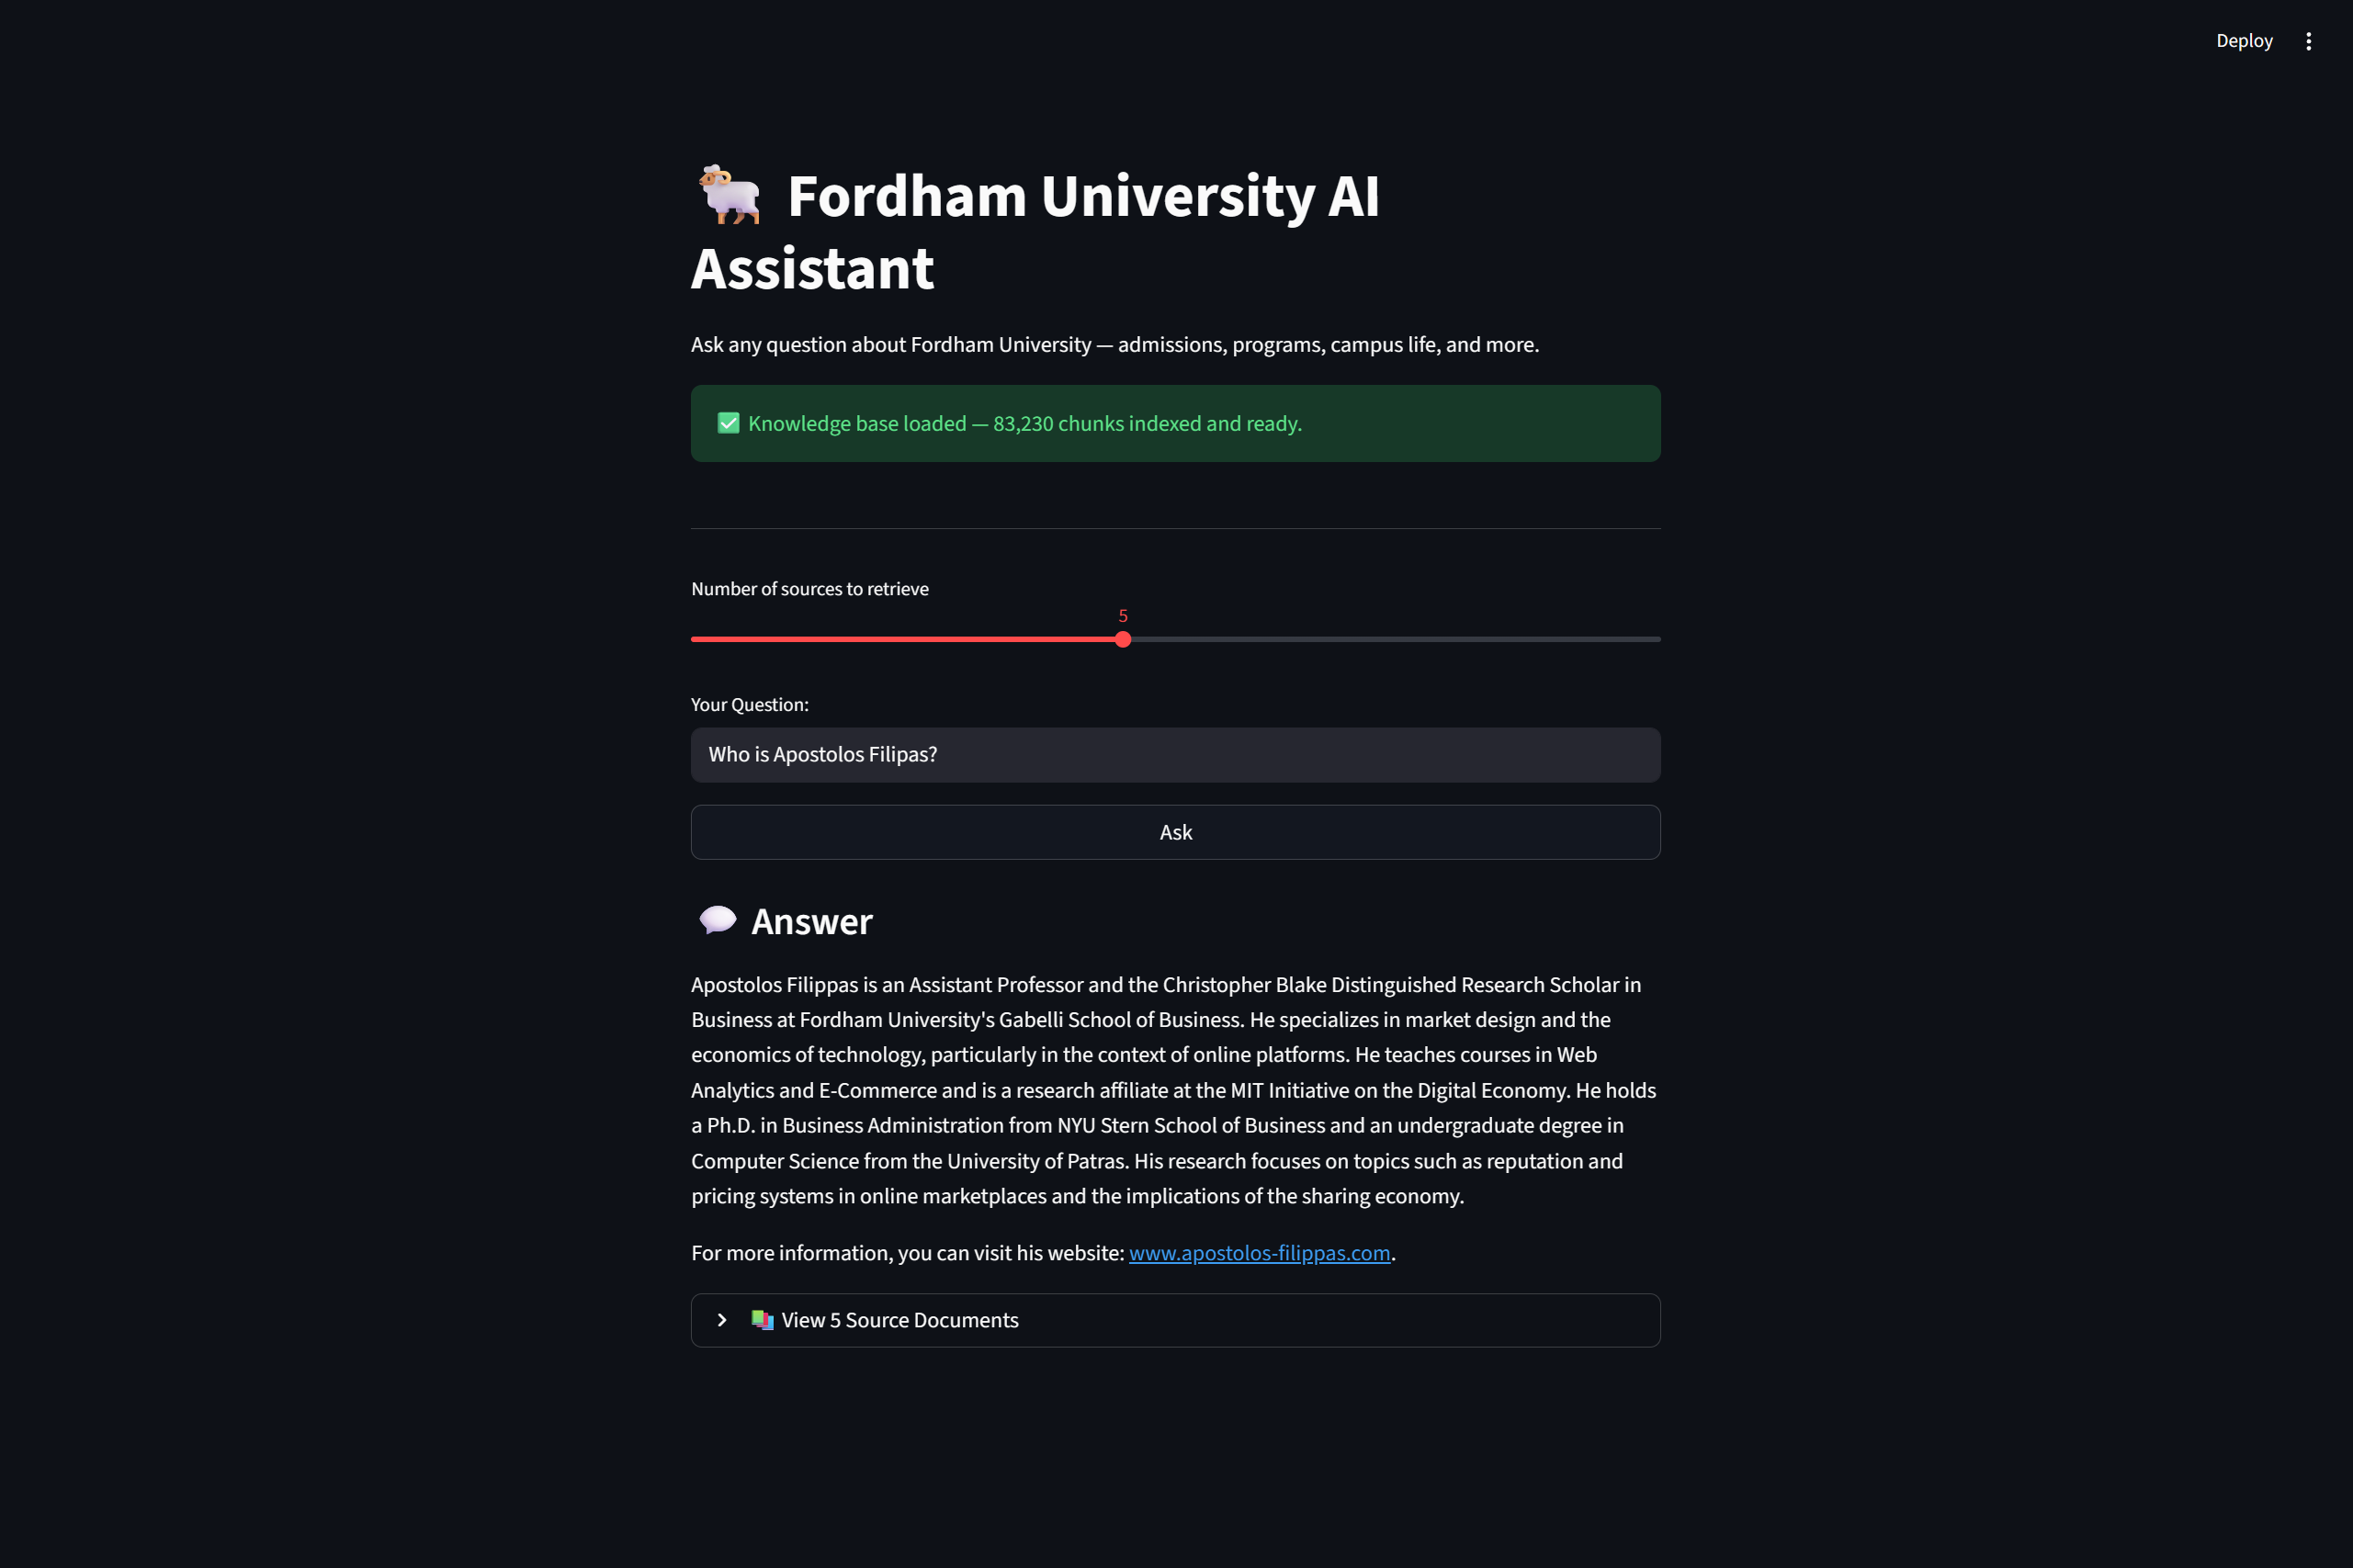

---

# Summary

## What You Built

| Step | What You Did | What It Does |
|------|-------------|-------------|
| **Load** | Read 9,500+ Fordham web pages | Get raw content |
| **Chunk** | Split pages into smaller pieces | Make content searchable and promptable |
| **Embed** | Turn chunks into vectors | Enable semantic search |
| **Retrieve** | Find relevant chunks for a question | The **R** in RAG |
| **Generate** | Ask an LLM to answer using the chunks | The **G** in RAG |
| **RAG** | Wire it all together | Question in, answer out |

## The Big Picture

RAG is one of the most common patterns in AI engineering today. What you built here is the same core architecture behind tools like ChatGPT with search, Perplexity, enterprise Q&A bots, and more. The details get more sophisticated (vector databases, reranking, query rewriting, evaluation) but the pattern is the same:

**Find relevant stuff → give it to an LLM → get an answer.**

You can just build things.